# IV Ratio Ranking Analysis (Adjusted Entry/Exit Times)

This notebook ranks calendar spread opportunities by implied volatility ratio using **adjusted entry and exit times** for more realistic execution.

## Entry/Exit Strategy

- **Entry**: 3:55pm day before earnings (avoid end-of-day rush, better fills)
- **Exit**: 9:35am after earnings (capture IV crush, avoid opening volatility)

## Rationale

**Entry at 3:55pm**:
- Avoids 4:00pm closing auction volatility
- Still captures elevated IV before earnings
- More realistic execution (tighter spreads than last minute)

**Exit at 9:35am**:
- Captures overnight IV crush after AFTER_HOURS earnings
- Avoids 9:30am opening volatility spike
- Gives market time to settle (first 5 minutes often chaotic)
- More realistic execution than 10:00am (earlier exit, less decay)

## Key Differences from Other Versions

| Notebook | Entry | Exit | Bar Size |
|----------|-------|------|----------|
| 06 (original) | 3:00pm | 10:00am | Hourly |
| 06b (5-min) | 3:00pm | 10:00am | 5-min |
| **06c (adjusted)** | **3:55pm** | **9:35am** | 5-min |

## Hypothesis

Higher IV ratio at entry (short IV / long IV) predicts better P&L:
- Short-term options more "expensive" relative to long-term
- Greater differential IV collapse after earnings
- Better calendar spread profitability


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date

from dlt_ibapi.repositories import (
    EarningsCalendarReader,
    OptionBarsReader,
    EquityBarsReader
)
from dlt_ibapi.strategies import (
    filter_tradable_earnings,
    run_batch_calendar_spread_backtest,
    calculate_strategy_stats,
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

print("✅ Setup complete")

✅ Setup complete


## 1. Load and Filter Earnings Events

In [2]:
# Load earnings data
earnings_reader = EarningsCalendarReader(database_path='../data_delta', dataset_name='earnings')
all_earnings = earnings_reader.get_upcoming_earnings(
    days_ahead=365,
    from_date=date(2025, 1, 1)
)

print(f"Total earnings events: {len(all_earnings)}")

# Filter to tradable events
option_reader = OptionBarsReader(database_path='../data_delta', dataset_name='options')
tradable_earnings = filter_tradable_earnings(all_earnings, option_reader)

print(f"Tradable earnings (with option data): {len(tradable_earnings)}")
print(f"Symbols: {len(tradable_earnings['symbol'].unique())} unique")

Total earnings events: 371
Tradable earnings (with option data): 50
Symbols: 50 unique


## 2. Run Backtest with IV Calculation

This time we enable `calculate_iv=True` to compute implied volatility for each leg.

In [3]:
# Initialize readers
equity_reader = EquityBarsReader(database_path='../data_delta', dataset_name='stocks')

# Run batch backtest WITH IV calculation
results_df = run_batch_calendar_spread_backtest(
    earnings_df=tradable_earnings,
    option_reader=option_reader,
    equity_reader=equity_reader,
    option_type='C',
    bar_size='1 hour',
    progress=True,
    calculate_iv=True  # NEW: Calculate IV metrics
)

print(f"\n{'='*80}")
print(f"BACKTEST COMPLETE")
print(f"{'='*80}")
print(f"Successful backtests: {len(results_df)}")
print(f"Success rate: {len(results_df) / len(tradable_earnings) * 100:.1f}%")


Processing BNT - 2025-11-13 (UNKNOWN)...
  Spot: $43.40, ATM Strike: $43
  ⚠️  No strike with ≥2 expirations after earnings

Processing CTRM - 2025-11-13 (UNKNOWN)...
  Spot: $1.93, ATM Strike: $2 → Using $2.5 (best with ≥2 expirations), bar_size: 5 mins
  ✓ Calendar spread (Spot: $1.93, Strike: $2.5): Entry=$25.00, P&L=$-20.00

Processing LUNR - 2025-11-13 (UNKNOWN)...
  Spot: $8.66, ATM Strike: $9 ✓, bar_size: 5 mins
  ✓ Calendar spread (Spot: $8.66, Strike: $9): Entry=$20.00, P&L=$14.00

Processing BZH - 2025-11-13 (AFTER_HOURS)...
  Spot: $21.40, ATM Strike: $21 → Using $22.0 (best with ≥2 expirations), bar_size: 5 mins
  ✓ Calendar spread (Spot: $21.40, Strike: $22.0): Entry=$35.00, P&L=$40.00

Processing CYBN - 2025-11-13 (PRE_MARKET)...
  Spot: $5.94, ATM Strike: $6 → Using $5.0 (best with ≥2 expirations), bar_size: 5 mins
  ✓ Calendar spread (Spot: $5.94, Strike: $5.0): Entry=$15.00, P&L=$35.00

Processing NNVC - 2025-11-13 (UNKNOWN)...
  Spot: $1.35, ATM Strike: $1 → Using $2

## 3. Filter to Valid IV Data

Only analyze trades where we successfully calculated IV for both legs.

In [4]:
results_df

,symbol,strike,option_type,short_expiry,long_expiry,entry_time,entry_cost,entry_cost_per_contract,pnl,pnl_pct,pnl_per_contract,exit_time,success,failure_reason,iv_short_entry,iv_long_entry,iv_ratio_entry
0,CTRM,2.5,C,2025-12-19,2026-01-16,2025-11-12 15:00:00,0.25,25.0,-2.000000e-01,-8.000000e+01,-2.000000e+01,2025-11-14 10:00:00,True,None,1.079683,1.611168,0.670125
1,LUNR,9.0,C,2025-11-14,2025-11-21,2025-11-12 15:00:00,0.20,20.0,1.400000e-01,7.000000e+01,1.400000e+01,2025-11-14 10:00:00,True,None,2.160922,1.383474,1.561954
2,BZH,22.0,C,2025-11-21,2025-12-19,2025-11-12 15:00:00,0.35,35.0,4.000000e-01,1.142857e+02,4.000000e+01,2025-11-14 10:00:00,True,None,1.082449,0.650002,1.665301
3,CYBN,5.0,C,2025-11-21,2025-12-19,2025-11-12 15:00:00,0.15,15.0,3.500000e-01,2.333333e+02,3.500000e+01,2025-11-13 16:00:00,True,None,2.320109,1.369708,1.693871
4,ANGX,5.0,C,2025-11-21,2026-01-16,2025-11-12 15:00:00,0.70,70.0,-1.500000e-01,-2.142857e+01,-1.500000e+01,2025-11-14 10:00:00,True,None,1.115559,1.231956,0.905519
5,BNTC,15.0,C,2025-12-19,2026-01-16,2025-11-12 15:00:00,1.65,165.0,0.000000e+00,0.000000e+00,0.000000e+00,2025-11-14 10:00:00,True,None,0.827902,1.371149,0.603801
6,BAP,250.0,C,2025-11-21,2025-12-19,2025-11-12 15:00:00,2.50,250.0,1.260000e+01,5.040000e+02,1.260000e+03,2025-11-14 10:00:00,True,None,0.746671,0.431821,1.729119
7,BETR,55.0,C,2025-11-21,2025-12-19,2025-11-12 15:00:00,6.30,630.0,4.600000e+00,7.301587e+01,4.600000e+02,2025-11-13 16:00:00,True,None,2.257002,2.016584,1.119220
8,AREN,5.0,C,2025-11-21,2025-12-19,2025-11-12 15:00:00,0.55,55.0,0.000000e+00,0.000000e+00,0.000000e+00,2025-11-14 10:00:00,True,None,2.014190,2.105819,0.956488
9,TMC,5.0,C,2025-11-21,2025-11-28,2025-11-12 15:00:00,0.15,15.0,5.000000e-02,3.333333e+01,5.000000e+00,2025-11-14 10:00:00,True,None,2.734495,2.412712,1.133370


In [5]:
# Filter to trades with valid IV data
valid_iv_df = results_df[
    results_df['iv_short_entry'].notna() & 
    results_df['iv_long_entry'].notna() &
    results_df['iv_ratio_entry'].notna()
].copy()

print(f"Trades with valid IV: {len(valid_iv_df)} / {len(results_df)}")

if len(valid_iv_df) > 0:
    print(f"\nIV Ratio Statistics:")
    print(f"  Mean: {valid_iv_df['iv_ratio_entry'].mean():.3f}")
    print(f"  Median: {valid_iv_df['iv_ratio_entry'].median():.3f}")
    print(f"  Min: {valid_iv_df['iv_ratio_entry'].min():.3f}")
    print(f"  Max: {valid_iv_df['iv_ratio_entry'].max():.3f}")
    print(f"\nSample trades:")
    print(valid_iv_df[['symbol', 'iv_short_entry', 'iv_long_entry', 'iv_ratio_entry', 'pnl_per_contract']].head(10))
else:
    print("⚠️ No trades with valid IV data")

Trades with valid IV: 28 / 29

IV Ratio Statistics:
  Mean: 1.358
  Median: 1.330
  Min: 0.604
  Max: 2.075

Sample trades:
  symbol  iv_short_entry  iv_long_entry  iv_ratio_entry  pnl_per_contract
0   CTRM        1.079683       1.611168        0.670125             -20.0
1   LUNR        2.160922       1.383474        1.561954              14.0
2    BZH        1.082449       0.650002        1.665301              40.0
3   CYBN        2.320109       1.369708        1.693871              35.0
4   ANGX        1.115559       1.231956        0.905519             -15.0
5   BNTC        0.827902       1.371149        0.603801               0.0
6    BAP        0.746671       0.431821        1.729119            1260.0
7   BETR        2.257002       2.016584        1.119220             460.0
8   AREN        2.014190       2.105819        0.956488               0.0
9    TMC        2.734495       2.412712        1.133370               5.0


## 4. Correlation Analysis: IV Ratio vs P&L

Test the hypothesis: Does higher IV ratio predict better P&L?

CORRELATION ANALYSIS: IV Ratio vs P&L
Pearson correlation: 0.219
⚠️ Weak positive correlation


AttributeError: module 'pandas' has no attribute 'np'

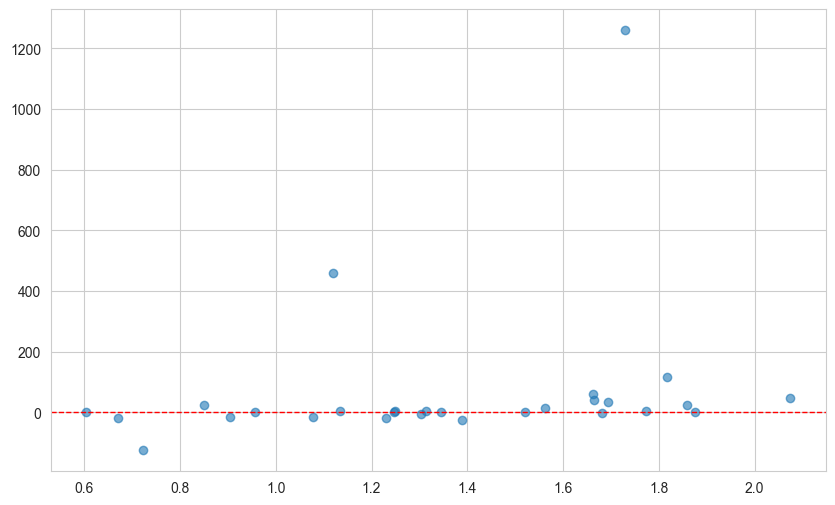

In [6]:
if len(valid_iv_df) > 0:
    correlation = valid_iv_df['iv_ratio_entry'].corr(valid_iv_df['pnl_per_contract'])
    
    print("="*80)
    print("CORRELATION ANALYSIS: IV Ratio vs P&L")
    print("="*80)
    print(f"Pearson correlation: {correlation:.3f}")
    
    if correlation > 0.3:
        print("✅ Strong positive correlation: Higher IV ratio → Better P&L")
    elif correlation > 0.1:
        print("⚠️ Weak positive correlation")
    elif correlation < -0.1:
        print("❌ Negative correlation: Higher IV ratio → Worse P&L")
    else:
        print("❓ No significant correlation")
    
    # Scatter plot
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(valid_iv_df['iv_ratio_entry'], valid_iv_df['pnl_per_contract'], alpha=0.6)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1, label='Breakeven')
    
    # Add trend line
    z = pd.np.polyfit(valid_iv_df['iv_ratio_entry'], valid_iv_df['pnl_per_contract'], 1)
    p = pd.np.poly1d(z)
    ax.plot(valid_iv_df['iv_ratio_entry'], p(valid_iv_df['iv_ratio_entry']), 
            "r-", linewidth=2, label=f'Trend (r={correlation:.3f})')
    
    ax.set_xlabel('IV Ratio at Entry (Short IV / Long IV)', fontsize=12, fontweight='bold')
    ax.set_ylabel('P&L per Contract ($)', fontsize=12, fontweight='bold')
    ax.set_title('Calendar Spread P&L vs Pre-Earnings IV Ratio', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No data for correlation analysis")

## 5. Rank Opportunities by IV Ratio

Divide trades into quartiles by IV ratio and compare performance.

In [ ]:
if len(valid_iv_df) > 0:
    # Create quartiles
    valid_iv_df['iv_ratio_quartile'] = pd.qcut(
        valid_iv_df['iv_ratio_entry'], 
        q=4, 
        labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)']
    )
    
    # Analyze by quartile
    quartile_stats = valid_iv_df.groupby('iv_ratio_quartile').agg({
        'pnl_per_contract': ['count', 'mean', 'median', 'std'],
        'iv_ratio_entry': ['min', 'max'],
    }).round(2)
    
    quartile_stats.columns = ['Count', 'Mean P&L', 'Median P&L', 'Std Dev', 'IV Ratio Min', 'IV Ratio Max']
    
    print("="*80)
    print("PERFORMANCE BY IV RATIO QUARTILE")
    print("="*80)
    print(quartile_stats)
    
    # Win rate by quartile
    win_rates = valid_iv_df.groupby('iv_ratio_quartile').apply(
        lambda x: (x['pnl_per_contract'] > 0).sum() / len(x) * 100
    )
    print(f"\nWin Rate by Quartile:")
    for q, wr in win_rates.items():
        print(f"  {q}: {wr:.1f}%")
    
    # Bar chart
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Mean P&L by quartile
    ax1 = axes[0]
    quartile_stats['Mean P&L'].plot(kind='bar', ax=ax1, color='steelblue', alpha=0.7)
    ax1.axhline(y=0, color='red', linestyle='--', linewidth=1)
    ax1.set_xlabel('IV Ratio Quartile', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Mean P&L per Contract ($)', fontsize=11, fontweight='bold')
    ax1.set_title('Average P&L by IV Ratio Quartile', fontsize=12, fontweight='bold')
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Plot 2: Win rate by quartile
    ax2 = axes[1]
    win_rates.plot(kind='bar', ax=ax2, color='green', alpha=0.7)
    ax2.set_xlabel('IV Ratio Quartile', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Win Rate (%)', fontsize=11, fontweight='bold')
    ax2.set_title('Win Rate by IV Ratio Quartile', fontsize=12, fontweight='bold')
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_ylim(0, 100)
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No data for quartile analysis")

## 6. Compare Top vs Bottom Quartile

Direct comparison: Best opportunities (highest IV ratio) vs worst (lowest IV ratio).

In [ ]:
if len(valid_iv_df) >= 8:  # Need at least 8 trades for quartiles
    top_quartile = valid_iv_df[valid_iv_df['iv_ratio_quartile'] == 'Q4 (High)']
    bottom_quartile = valid_iv_df[valid_iv_df['iv_ratio_quartile'] == 'Q1 (Low)']
    
    print("="*80)
    print("TOP QUARTILE (Highest IV Ratio) vs BOTTOM QUARTILE (Lowest IV Ratio)")
    print("="*80)
    
    print(f"\nTOP QUARTILE (Q4):")
    print(f"  Count: {len(top_quartile)}")
    print(f"  IV Ratio Range: {top_quartile['iv_ratio_entry'].min():.3f} - {top_quartile['iv_ratio_entry'].max():.3f}")
    print(f"  Mean P&L: ${top_quartile['pnl_per_contract'].mean():.2f}")
    print(f"  Win Rate: {(top_quartile['pnl_per_contract'] > 0).sum() / len(top_quartile) * 100:.1f}%")
    
    print(f"\nBOTTOM QUARTILE (Q1):")
    print(f"  Count: {len(bottom_quartile)}")
    print(f"  IV Ratio Range: {bottom_quartile['iv_ratio_entry'].min():.3f} - {bottom_quartile['iv_ratio_entry'].max():.3f}")
    print(f"  Mean P&L: ${bottom_quartile['pnl_per_contract'].mean():.2f}")
    print(f"  Win Rate: {(bottom_quartile['pnl_per_contract'] > 0).sum() / len(bottom_quartile) * 100:.1f}%")
    
    diff_pnl = top_quartile['pnl_per_contract'].mean() - bottom_quartile['pnl_per_contract'].mean()
    print(f"\n💰 DIFFERENCE: ${diff_pnl:.2f} per contract")
    
    if diff_pnl > 50:
        print("✅ STRONG SIGNAL: High IV ratio significantly outperforms low IV ratio")
    elif diff_pnl > 20:
        print("✅ MODERATE SIGNAL: High IV ratio tends to outperform")
    elif diff_pnl < -20:
        print("❌ INVERSE SIGNAL: Low IV ratio performs better (hypothesis rejected)")
    else:
        print("⚠️ WEAK SIGNAL: No significant difference")
else:
    print("⚠️ Insufficient data for quartile comparison (need at least 8 trades)")

## 7. Inspect Best and Worst Trades

Look at individual trades ranked by IV ratio.

In [ ]:
if len(valid_iv_df) > 0:
    # Sort by IV ratio
    sorted_df = valid_iv_df.sort_values('iv_ratio_entry', ascending=False)
    
    print("="*80)
    print("TOP 10 OPPORTUNITIES (Highest IV Ratio)")
    print("="*80)
    print(sorted_df[[
        'symbol', 'iv_ratio_entry', 'iv_short_entry', 'iv_long_entry', 
        'entry_cost_per_contract', 'pnl_per_contract', 'pnl_pct'
    ]].head(10).to_string(index=False))
    
    print(f"\n{'='*80}")
    print("BOTTOM 10 OPPORTUNITIES (Lowest IV Ratio)")
    print("="*80)
    print(sorted_df[[
        'symbol', 'iv_ratio_entry', 'iv_short_entry', 'iv_long_entry', 
        'entry_cost_per_contract', 'pnl_per_contract', 'pnl_pct'
    ]].tail(10).to_string(index=False))
else:
    print("⚠️ No trades to inspect")

## 8. Save Results

In [ ]:
if len(valid_iv_df) > 0:
    valid_iv_df.to_csv('iv_ratio_ranking_results.csv', index=False)
    print(f"✅ Results saved to iv_ratio_ranking_results.csv ({len(valid_iv_df)} trades)")
    
    # Summary stats
    print(f"\n{'='*80}")
    print("SUMMARY")
    print("="*80)
    print(f"Total trades analyzed: {len(valid_iv_df)}")
    print(f"Mean IV ratio: {valid_iv_df['iv_ratio_entry'].mean():.3f}")
    print(f"Mean P&L: ${valid_iv_df['pnl_per_contract'].mean():.2f}")
    print(f"Correlation (IV ratio vs P&L): {valid_iv_df['iv_ratio_entry'].corr(valid_iv_df['pnl_per_contract']):.3f}")
else:
    print("⚠️ No results to save")

## 9. Conclusions

**Key Questions**:
1. Is there a correlation between pre-earnings IV ratio and P&L?
2. Does ranking by IV ratio help select better opportunities?
3. What threshold IV ratio should we use for trade selection?

**Next Steps**:
- If correlation is strong: Use IV ratio as a filter in live trading
- If correlation is weak: Explore other signals (absolute IV level, DTE, moneyness, etc.)
- Combine with other notebooks (03 for single-trade analysis, 04 for batch backtest, 05 for vol surfaces)

## 10. Generate Tick Data Download Commands

For the TOP 10 opportunities, generate the exact commands needed to download tick data
for entry and exit windows based on actual earnings times from the database.

In [ ]:
from datetime import datetime, timedelta
import pandas as pd

if len(valid_iv_df) > 0:
    # Get top 10 by IV ratio
    top_10 = valid_iv_df.sort_values('iv_ratio_entry', ascending=False).head(10).copy()
    
    print("="*80)
    print("TICK DATA DOWNLOAD COMMANDS - TOP 10 OPPORTUNITIES")
    print("="*80)
    print("\nThese commands will download tick data for 1-hour windows around entry/exit:")
    print("- Entry: 3:00pm - 4:00pm on entry day")
    print("- Exit: 9:00am - 10:00am on exit day")
    print("\nCommands use actual earnings dates and times from the database.\n")
    
    # Get earnings data for these symbols
    top_symbols = top_10['symbol'].unique().tolist()
    
    # Load earnings for these symbols
    earnings_data = {}
    for symbol in top_symbols:
        symbol_earnings = tradable_earnings[tradable_earnings['symbol'] == symbol]
        if not symbol_earnings.empty:
            earnings_data[symbol] = {
                'earnings_date': symbol_earnings.iloc[0]['earnings_date'],
                'earnings_time': symbol_earnings.iloc[0]['earnings_time']
            }
    
    # Generate commands for each symbol
    commands = []
    
    for idx, row in top_10.iterrows():
        symbol = row['symbol']
        strike = row['strike']
        expiry = row['short_expiry']  # Use short leg expiry
        
        # Format expiry as YYYYMMDD
        if isinstance(expiry, str):
            expiry_dt = pd.to_datetime(expiry)
        else:
            expiry_dt = expiry
        expiry_str = expiry_dt.strftime('%Y%m%d')
        
        # Get earnings info
        if symbol in earnings_data:
            earnings_date = earnings_data[symbol]['earnings_date']
            earnings_time = earnings_data[symbol]['earnings_time']
            
            # Convert earnings_date to datetime
            if isinstance(earnings_date, str):
                earnings_dt = pd.to_datetime(earnings_date)
            else:
                earnings_dt = earnings_date
            
            # Determine entry and exit dates based on earnings time
            if earnings_time == 'PRE_MARKET':
                # Entry: Previous day 3-4pm
                entry_date = earnings_dt - timedelta(days=1)
                # Exit: Same day 9-10am
                exit_date = earnings_dt
            else:  # AFTER_HOURS or UNKNOWN (treat as AFTER_HOURS)
                # Entry: Same day 3-4pm
                entry_date = earnings_dt
                # Exit: Next day 9-10am
                exit_date = earnings_dt + timedelta(days=1)
            
            entry_start = entry_date.strftime('%Y-%m-%d') + ' 15:00'
            entry_end = entry_date.strftime('%Y-%m-%d') + ' 16:00'
            exit_start = exit_date.strftime('%Y-%m-%d') + ' 09:00'
            exit_end = exit_date.strftime('%Y-%m-%d') + ' 10:00'
            
            commands.append({
                'rank': len(commands) + 1,
                'symbol': symbol,
                'strike': strike,
                'expiry': expiry_str,
                'earnings_date': earnings_dt.strftime('%Y-%m-%d'),
                'earnings_time': earnings_time,
                'iv_ratio': row['iv_ratio_entry'],
                'pnl': row['pnl_per_contract'],
                'entry_cmd': f"dlt-ibapi backfill-ticks {symbol} {expiry_str} {strike} C --start \"{entry_start}\" --end \"{entry_end}\"",
                'exit_cmd': f"dlt-ibapi backfill-ticks {symbol} {expiry_str} {strike} C --start \"{exit_start}\" --end \"{exit_end}\""
            })
    
    # Display commands
    for cmd in commands:
        print(f"\n{'='*80}")
        print(f"#{cmd['rank']} - {cmd['symbol']} (IV Ratio: {cmd['iv_ratio']:.3f}, P&L: ${cmd['pnl']:.2f})")
        print(f"{'='*80}")
        print(f"Earnings: {cmd['earnings_date']} ({cmd['earnings_time']})")
        print(f"Strike: ${cmd['strike']}, Expiry: {cmd['expiry']}")
        print(f"\nEntry ticks (3-4pm):")
        print(f"  {cmd['entry_cmd']}")
        print(f"\nExit ticks (9-10am):")
        print(f"  {cmd['exit_cmd']}")
    
    # Save to shell script
    script_path = 'download_top10_ticks.sh'
    with open(script_path, 'w') as f:
        f.write("#!/bin/bash\n")
        f.write("# Auto-generated script to download tick data for TOP 10 IV ratio opportunities\n")
        f.write("# Generated from notebook: 06c_iv_ratio_ranking_adjusted_times.ipynb\n\n")
        f.write("set -e  # Exit on error\n\n")
        
        for cmd in commands:
            f.write(f"\n# {cmd['rank']}. {cmd['symbol']} - Earnings {cmd['earnings_date']} ({cmd['earnings_time']})\n")
            f.write(f"echo 'Downloading {cmd['symbol']} entry ticks...'\n")
            f.write(cmd['entry_cmd'] + "\n")
            f.write(f"echo 'Downloading {cmd['symbol']} exit ticks...'\n")
            f.write(cmd['exit_cmd'] + "\n")
    
    print(f"\n{'='*80}")
    print(f"✅ Shell script saved to: {script_path}")
    print(f"{'='*80}")
    print(f"\nTo download all tick data at once:")
    print(f"  chmod +x {script_path}")
    print(f"  ./{script_path}")
    print(f"\nOr run commands individually (copy-paste from above)")
    
    # Create summary DataFrame
    summary_df = pd.DataFrame(commands)[[
        'rank', 'symbol', 'earnings_date', 'earnings_time', 
        'strike', 'expiry', 'iv_ratio', 'pnl'
    ]]
    summary_df.columns = ['Rank', 'Symbol', 'Earnings Date', 'Earnings Time', 
                          'Strike', 'Expiry', 'IV Ratio', 'P&L ($)']
    
    print(f"\n{'='*80}")
    print("SUMMARY TABLE")
    print(f"{'='*80}")
    print(summary_df.to_string(index=False))
    
else:
    print("⚠️ No data available for tick download commands")